In [ ]:
import pandas as pd
import numpy as np

# Veri yükleme
df = pd.read_excel("guncellenmis_veri_seti_son (1) (2).xlsx")

# 1. Veri Temizliği ve Seçimi
model_veri = df.copy()
model_veri = model_veri[model_veri['Bölge'] == 1]  # Bölge 1'e odaklanıyoruz (Bölge sayısal ise '1' kullanın)
model_veri.dropna(inplace=True)  # Eksik değerleri temizleme





In [5]:
model_veri

,Bölge,Gün,Ay,Yıl,Saat,Dakika,Mevsim,v2_Avg,v2_Std,v2_Min,...,Normal Sıcaklık,Potansiyel Sıcaklık,Basınç,Yoğunluk,Türbülans Yoğunluğu,WSE(Rüzgar Kayması),Girdap Geçişi(Eddy),Dinamik Momentum Taşınımı,monin obukhov,Güç
0,1,27,7,2016,12,40,2,8.400,1.141,0.000,...,25.83,29.21,1012.490,1.179,0.420747,0.064760,0.901333,-0.405045,6158.367910,726.5
1,1,27,7,2016,12,50,2,7.672,1.084,4.786,...,25.80,29.48,1012.470,1.179,0.460672,-0.005362,1.532267,-0.694942,2759.922141,596.2
2,1,27,7,2016,13,0,2,8.720,0.899,5.845,...,25.91,29.60,1012.479,1.179,0.405307,0.114120,0.450667,-0.205227,13779.339357,648.8
3,1,27,7,2016,13,10,2,8.060,1.207,4.579,...,25.90,29.74,1012.465,1.179,0.438496,0.101349,2.704000,-1.237184,1813.552944,637.7
4,1,27,7,2016,13,20,2,7.644,1.048,5.270,...,26.00,29.92,1012.450,1.179,0.462360,0.119251,5.678400,-2.613811,736.706385,727.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36447,1,12,4,2017,9,50,1,6.272,0.888,4.004,...,10.61,16.46,1017.261,1.248,0.563501,0.005590,2.478667,-0.627675,926.246079,529.4
36448,1,12,4,2017,10,0,1,6.358,0.704,4.303,...,10.37,16.33,1017.246,1.249,0.555879,-0.028312,1.712533,-0.430241,1396.435155,471.7
36449,1,12,4,2017,10,10,1,6.357,0.813,4.096,...,10.31,16.06,1017.151,1.250,0.555966,-0.054673,2.298400,-0.567882,1039.973937,411.5
36450,1,12,4,2017,10,20,1,6.312,0.776,3.912,...,10.24,15.69,1017.116,1.250,0.559930,0.002939,3.470133,-0.837637,674.276762,321.5


In [9]:
# 2. Zaman Sütununu İndekse Alma
model_veri['TarihSaat'] = pd.to_datetime({
    'year': model_veri['Yıl'], 
    'month': model_veri['Ay'], 
    'day': model_veri['Gün'], 
    'hour': model_veri['Saat'], 
    'minute': model_veri['Dakika']
})  # Zamanı datetime formatına dönüştür
model_veri.set_index('TarihSaat', inplace=True)  # 'TarihSaat' sütununu indeks olarak ayarla

# 3. Gecikmeli Özellikler
model_veri['Güç_Lag1'] = model_veri['Güç'].shift(1).astype(float)
model_veri['Güç_Lag2'] = model_veri['Güç'].shift(2).astype(float)



# 4. Rolling İstatistikler
model_veri['Rolling_Mean'] = model_veri['Güç'].rolling(window=3).mean()

# 5. Zamanla İlgili Özellikler
model_veri['Hour'] = model_veri.index.hour  # Saat
model_veri['Day'] = model_veri.index.day  # Gün
model_veri['Month'] = model_veri.index.month  # Ay
model_veri['Day_of_Week'] = model_veri.index.dayofweek  # Haftanın günü (0= Pazartesi, 6= Pazar)
model_veri['Is_Weekend'] = (model_veri['Day_of_Week'] >= 5).astype(int)  # Hafta sonu kontrolü (1 = Hafta sonu)
model_veri['Season'] = model_veri['Month'] % 12 // 3 + 1  # Mevsimi belirleme (1: Kış, 2: İlkbahar, 3: Yaz, 4: Sonbahar)

# 6. Gecikmeli Etkileşimler (Lag Etkileşimleri)
# Şimdi etkileşim sütunlarını oluşturun
model_veri['Power_Lag1_Interaction'] = model_veri['Güç_Lag1'] * model_veri['Rüzgar Yönü ortalama'].astype(float)
model_veri['Power_Lag2_Interaction'] = model_veri['Güç_Lag2'] * model_veri['Rüzgar Yönü ortalama'].astype(float)

# 7. Diğer Özellikler
model_veri['Cumulative_Sum'] = model_veri['Güç'].cumsum()  # Kümülatif toplam
model_veri['Trend'] = np.arange(len(model_veri))  # Zamanla değişen trend
model_veri['Power_Weather_Interaction'] = model_veri['Güç'] * model_veri['Yağış Miktarı Ortalaması']  # Güç ve hava durumu etkileşimi

# 8. Eksik Verileri Temizleme (Eksik veri varsa sıfırla doldur)
model_veri.fillna(0, inplace=True)

# Verinin son halini kontrol etme
print(model_veri.head())

                     Bölge  Gün  Ay   Yıl  Saat  Dakika  Mevsim  v2_Avg  \
TarihSaat                                                                 
2016-07-27 12:40:00      1   27   7  2016    12      40       2   8.400   
2016-07-27 12:50:00      1   27   7  2016    12      50       2   7.672   
2016-07-27 13:00:00      1   27   7  2016    13       0       2   8.720   
2016-07-27 13:10:00      1   27   7  2016    13      10       2   8.060   
2016-07-27 13:20:00      1   27   7  2016    13      20       2   7.644   

                     v2_Std  v2_Min  ...  Day  Month Day_of_Week  Is_Weekend  \
TarihSaat                            ...                                       
2016-07-27 12:40:00   1.141   0.000  ...   27      7           2           0   
2016-07-27 12:50:00   1.084   4.786  ...   27      7           2           0   
2016-07-27 13:00:00   0.899   5.845  ...   27      7           2           0   
2016-07-27 13:10:00   1.207   4.579  ...   27      7           2          

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [17]:
print(model_veri['Rüzgar Yönü ortalama'].dtype)  # Veri tipini kontrol etme

object


In [18]:
model_veri['Rüzgar Yönü ortalama'] = pd.to_numeric(model_veri['Rüzgar Yönü ortalama'], errors='coerce')

In [19]:
print(model_veri.select_dtypes(include=['object']).columns)  # Sayısal olmayan sütunları listele

Index([], dtype='object')


In [21]:
X = model_veri.drop(columns=['Güç']).values
y = model_veri['Güç'].values

In [22]:
scaler = MinMaxScaler()
X_scaled = X

In [23]:
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

In [24]:
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X_reshaped):
    X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
    y_train, y_test = y[train_index], y[test_index]

In [25]:
# LSTM Modeli oluşturma
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_reshaped.shape[1], 1)),
    Dropout(0.1),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.1),
    LSTM(32, activation='tanh'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(1)  # Çıkış katmanı
])
print("LSTM Modeli Kuruldu")
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print(model.summary())

LSTM Modeli Kuruldu


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 38, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 38, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,737 (518.50 KB)

 Trainable params: 132,737 (518.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Model eğitimi
history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler],
    verbose=2
)

# Model değerlendirme
y_pred = model.predict(X_test)

Epoch 1/200
1519/1519 - 56s - 37ms/step - loss: 13600.2422 - mae: 46.5412 - val_loss: 1376.3279 - val_mae: 15.8186 - learning_rate: 0.0010
Epoch 2/200
1519/1519 - 55s - 36ms/step - loss: 2258.0066 - mae: 22.1522 - val_loss: 1080.6812 - val_mae: 11.9012 - learning_rate: 0.0010
Epoch 3/200
1519/1519 - 52s - 34ms/step - loss: 1827.4874 - mae: 19.7998 - val_loss: 1043.4457 - val_mae: 10.6511 - learning_rate: 0.0010
Epoch 4/200
1519/1519 - 48s - 32ms/step - loss: 1690.9275 - mae: 18.9823 - val_loss: 815.7407 - val_mae: 9.1476 - learning_rate: 0.0010
Epoch 5/200
1519/1519 - 49s - 32ms/step - loss: 1649.0695 - mae: 18.5537 - val_loss: 937.8507 - val_mae: 10.2146 - learning_rate: 0.0010
Epoch 6/200
1519/1519 - 51s - 33ms/step - loss: 1541.5624 - mae: 18.1579 - val_loss: 745.9547 - val_mae: 7.8157 - learning_rate: 0.0010
Epoch 7/200
1519/1519 - 47s - 31ms/step - loss: 1506.5920 - mae: 17.7982 - val_loss: 840.4641 - val_mae: 9.6976 - learning_rate: 0.0010
Epoch 8/200
1519/1519 - 48s - 32ms/step 

In [30]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Skoru: {r2}")

# Modeli kaydetme
model.save('model.h5')

R2 Skoru: 0.999267790174916


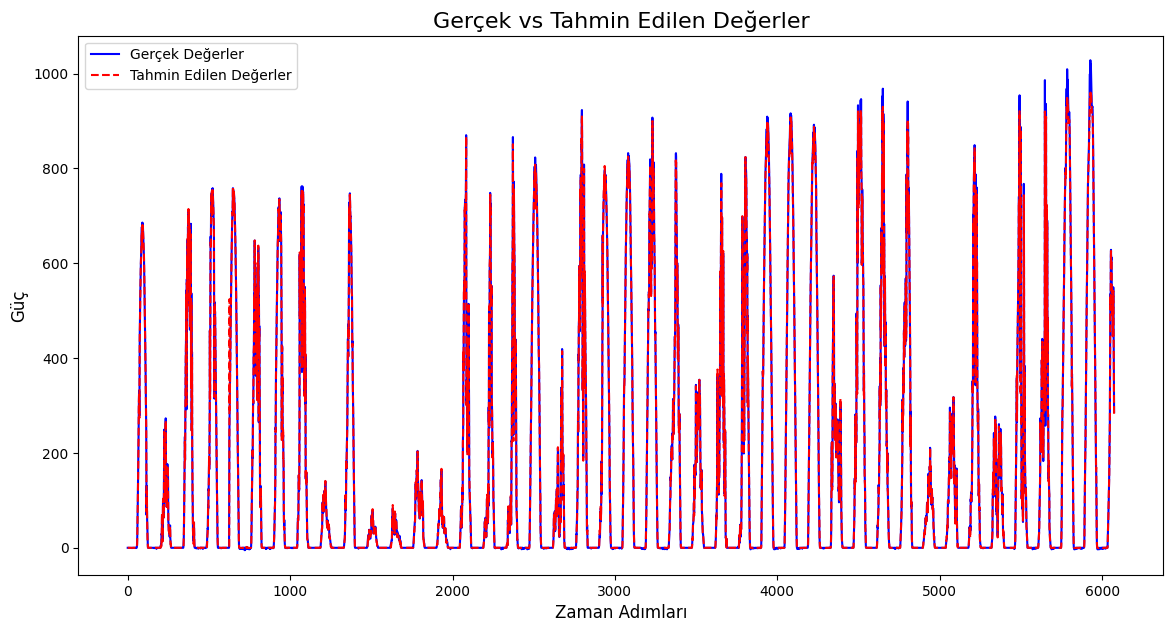

In [28]:
import matplotlib.pyplot as plt

# Gerçek ve tahmin edilen değerlerin karşılaştırılması
plt.figure(figsize=(14, 7))

# Gerçek değerler
plt.plot(y_test, label='Gerçek Değerler', color='blue')

# Tahmin edilen değerler
plt.plot(y_pred, label='Tahmin Edilen Değerler', color='red', linestyle='--')

# Grafik başlıkları ve etiketler
plt.title('Gerçek vs Tahmin Edilen Değerler', fontsize=16)
plt.xlabel('Zaman Adımları', fontsize=12)
plt.ylabel('Güç', fontsize=12)
plt.legend()
plt.savefig("'Gerçek vs Tahmin Edilen Değerler.png")
# Grafiği gösterme
plt.show()


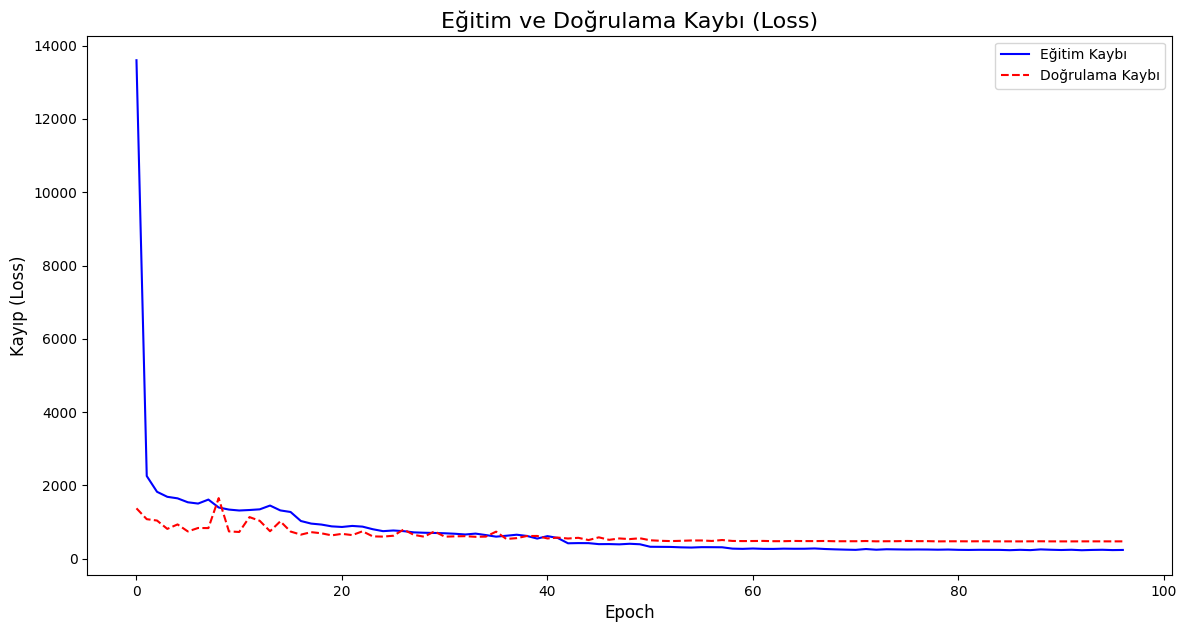

In [31]:
# Eğitim ve doğrulama kaybı grafiği
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Eğitim Kaybı', color='blue')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı', color='red', linestyle='--')

plt.title('Eğitim ve Doğrulama Kaybı (Loss)', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Kayıp (Loss)', fontsize=12)
plt.legend()
plt.savefig("Eğitim ve Doğrulama Kaybı (Loss).png")
# Grafiği gösterme
plt.show()



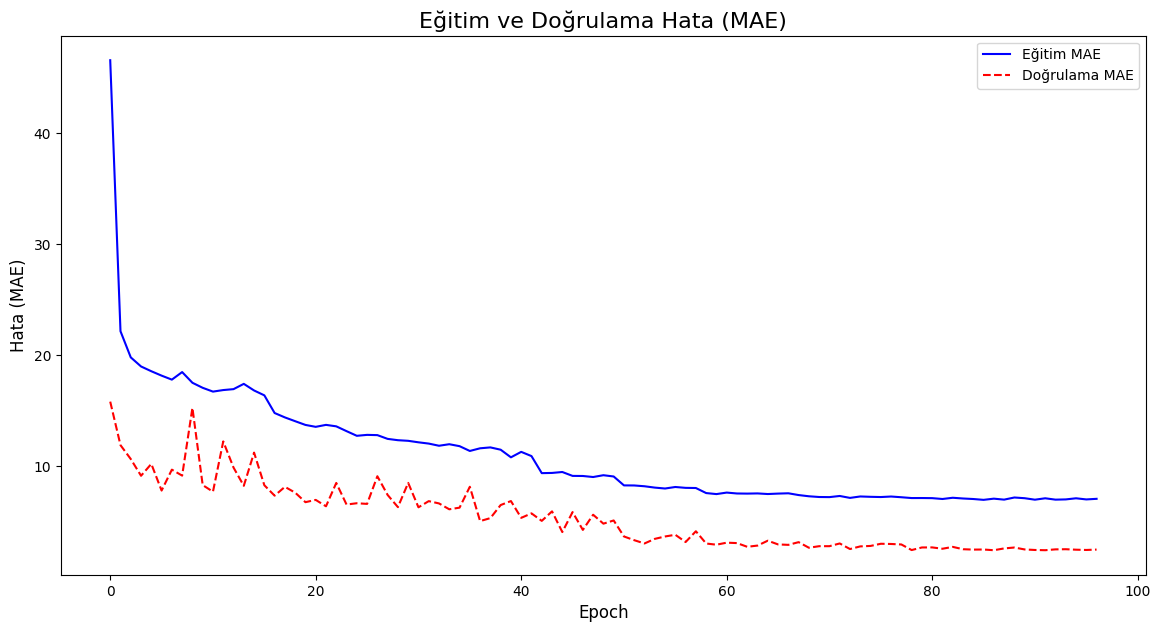

In [32]:
# Eğitim ve doğrulama MAE grafiği
plt.figure(figsize=(14, 7))
plt.plot(history.history['mae'], label='Eğitim MAE', color='blue')
plt.plot(history.history['val_mae'], label='Doğrulama MAE', color='red', linestyle='--')

plt.title('Eğitim ve Doğrulama Hata (MAE)', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Hata (MAE)', fontsize=12)
plt.legend()

plt.savefig("Eğitim ve Doğrulama Hata (MAE).png")
# Grafiği gösterme
plt.show()


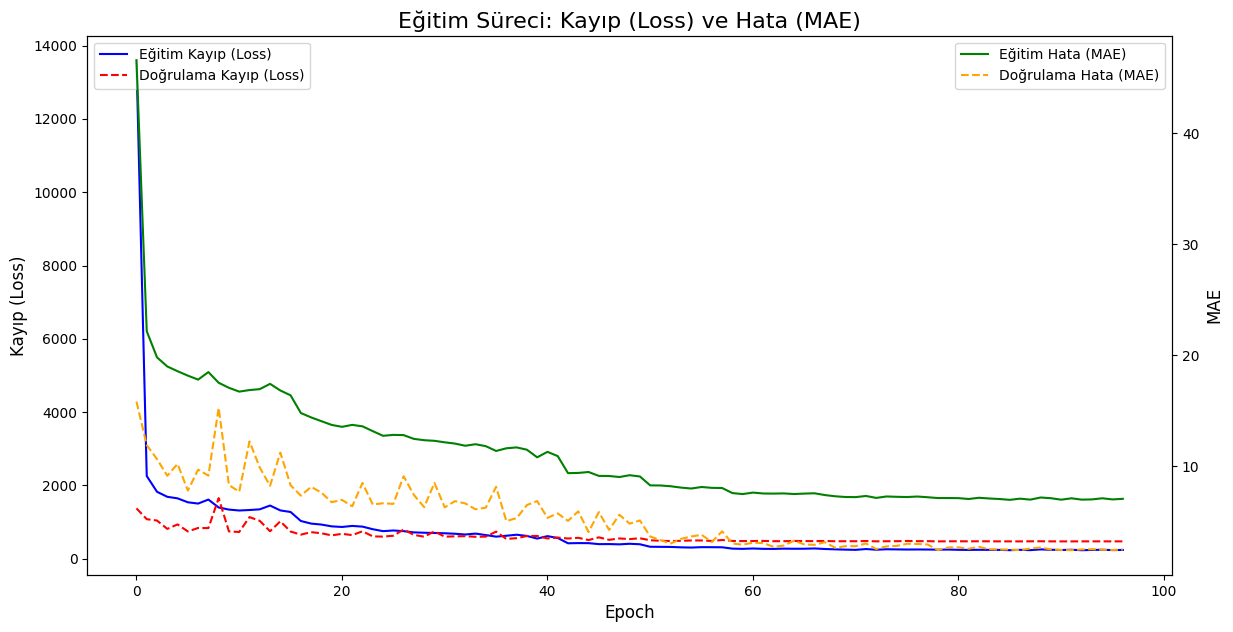

In [33]:
# Kayıp (Loss) ve Hata (MAE) karşılaştırma grafiği
fig, ax1 = plt.subplots(figsize=(14, 7))

# Kaybın (Loss) grafiği
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Kayıp (Loss)', fontsize=12)
ax1.plot(history.history['loss'], label='Eğitim Kayıp (Loss)', color='blue')
ax1.plot(history.history['val_loss'], label='Doğrulama Kayıp (Loss)', color='red', linestyle='--')
ax1.legend(loc='upper left')

# Hata (MAE) için ikinci eksen
ax2 = ax1.twinx()
ax2.set_ylabel('MAE', fontsize=12)
ax2.plot(history.history['mae'], label='Eğitim Hata (MAE)', color='green')
ax2.plot(history.history['val_mae'], label='Doğrulama Hata (MAE)', color='orange', linestyle='--')
ax2.legend(loc='upper right')

# Başlık
plt.title('Eğitim Süreci: Kayıp (Loss) ve Hata (MAE)', fontsize=16)
plt.savefig("Eğitim Süreci Kayıp (Loss) ve Hata (MAE).png")
# Grafiği gösterme
plt.show()


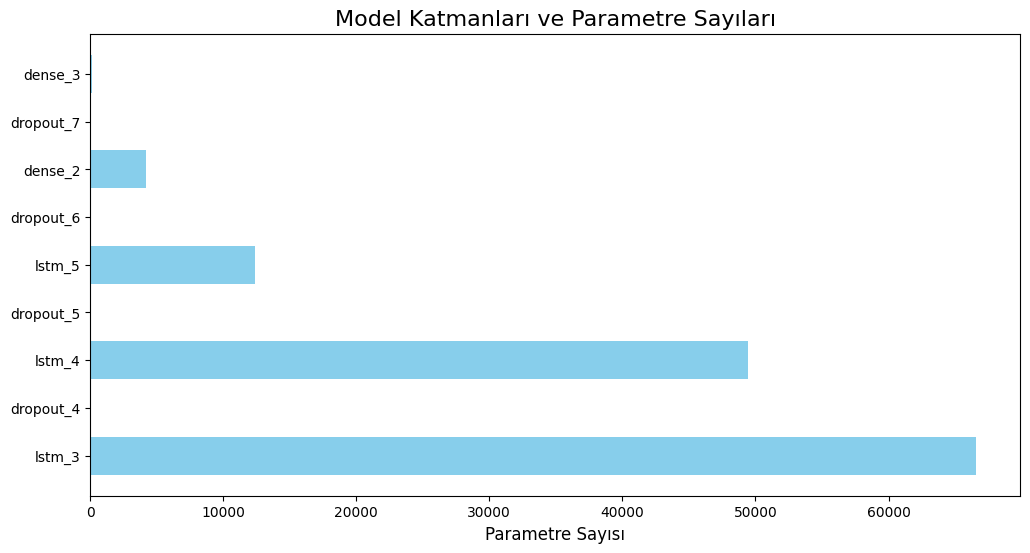

  Katman İsmi Katman Tipi  Parametre Sayısı
0      lstm_3        LSTM             66560
1   dropout_4     Dropout                 0
2      lstm_4        LSTM             49408
3   dropout_5     Dropout                 0
4      lstm_5        LSTM             12416
5   dropout_6     Dropout                 0
6     dense_2       Dense              4224
7   dropout_7     Dropout                 0
8     dense_3       Dense               129


In [34]:
import matplotlib.pyplot as plt

# Modelin katmanları ve parametreleri
layer_names = [layer.name for layer in model.layers]
layer_types = [layer.__class__.__name__ for layer in model.layers]
layer_params = [layer.count_params() for layer in model.layers]

# Görselleştirme için veri çerçevesi oluşturma
df = pd.DataFrame({
    'Katman İsmi': layer_names,
    'Katman Tipi': layer_types,
    'Parametre Sayısı': layer_params
})

# Katmanlar ve parametreleri gösterme
plt.figure(figsize=(12, 6))
plt.barh(df['Katman İsmi'], df['Parametre Sayısı'], color='skyblue')
plt.xlabel('Parametre Sayısı', fontsize=12)
plt.title('Model Katmanları ve Parametre Sayıları', fontsize=16)
plt.show()

# Katmanların bilgilerini yazdırma
print(df)


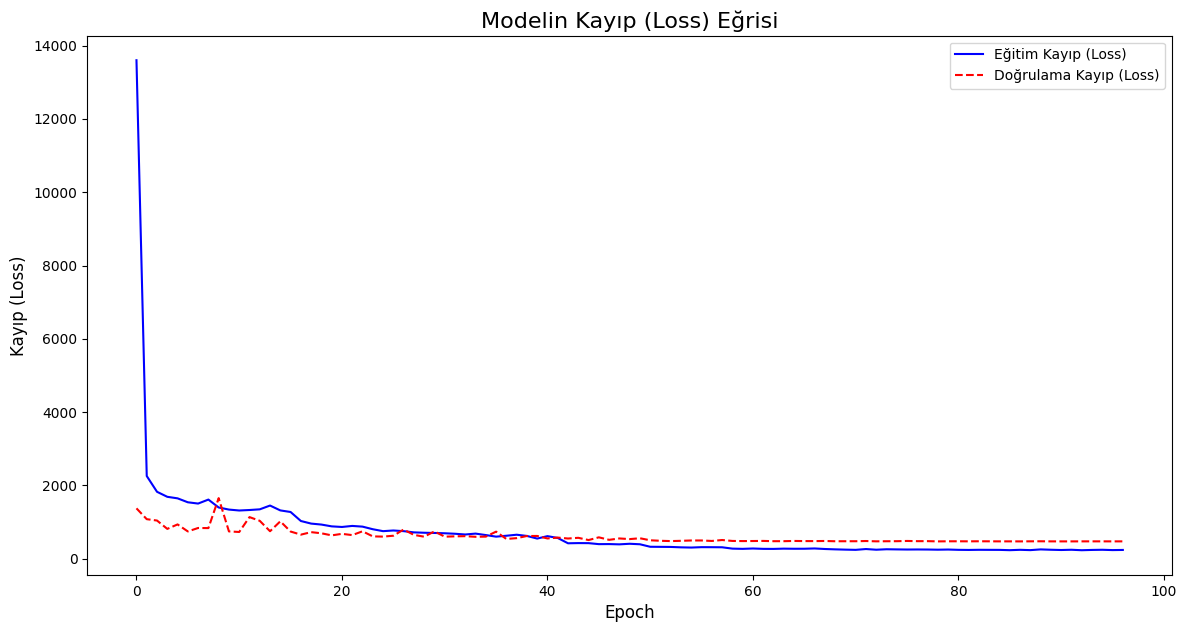

In [35]:
# Eğitim sırasında kayıp (Loss) grafiği
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Eğitim Kayıp (Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Doğrulama Kayıp (Loss)', color='red', linestyle='--')
plt.title('Modelin Kayıp (Loss) Eğrisi', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Kayıp (Loss)', fontsize=12)
plt.legend()
plt.savefig("Modelin Kayıp (Loss) Eğrisi.png")
plt.show()
